# AFCON 2023 Final: Data Analysis
## Nigeria 🇳🇬 vs Ivory Coast 🇨🇮 | February 11, 2024
## Notebook Series - Part B: Team's Passing Network

## Table of Contents
1. [Introduction](#introduction)
2. [Acquiring Data](#acquring-data)
3. [Data Filtering](#data-filtering)
4. [Contextualize Dataset](#contextualize-dataset)
5. [Derive the Player Positions](#player-positions)
6. [Building the Passing Network](#building-network)
7. [Visualising the Network](#visualising-network)
8. [Interpretation](#interpretation)
9. [Summary Statistics](#summary)

<a id="introduction"></a>
## 1. Introduction

Notebook Series - Part B: Team's Passing Network

**Task**
Using `StatsBomb` open event data, load the AFCON 2023 Final between Nigeria and Ivory Coast, select the Ivory Coast squad, and create their passing network. Each node represents a player and edge represents the passing connections.

---
> **Data Source:** [StatsBomb Open Data](https://github.com/statsbomb/open-data)  
> **competition_id:** 1267  
> **season_id:** 107  
> **match_id:** 3923881  
> **Team Analysed:** Ivory Coast, 
> **Context:** Open play completed passes before the first substitution was made.
---

### 1.1 Import the required libraries 

In [1]:
# Import core libraries 
import math 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

from statsbombpy import sb
from mplsoccer import Pitch, Sbopen, VerticalPitch

<a id="acquiring-data"></a>
## 2. Acquiring Data

Using the `Sbopen` parser in the `mplsoccer` library access the matches table and event table. Then select the competition `African Cup of Nations` with `competition_id = 1267`, `season_id = 107` and `match_id = 3923881`.


### 2.1. Load competitions, matches and event data

In [2]:
# Initialize the Statsbomb open-data parser 
parser = Sbopen()

In [3]:
# List top 20 competitions
df_comp = parser.competition()
df_comp[['competition_id', 'season_id', 'competition_name', 'season_id']].head(20)

,competition_id,season_id,competition_name,season_id
0,9,281,1. Bundesliga,281
1,9,27,1. Bundesliga,27
2,1267,107,African Cup of Nations,107
3,16,4,Champions League,4
4,16,1,Champions League,1
5,16,2,Champions League,2
6,16,27,Champions League,27
7,16,26,Champions League,26
8,16,25,Champions League,25
9,16,24,Champions League,24


### 2.2 Initialize match details

In [4]:
# Match details
competition_id = 1267
season_id = 107
match_id = 3923881

### 2.3 Load the matches table & events

In [5]:
# Load the match & it's related events
df_match = parser.match(competition_id, season_id)

# Load events 
df_event, df_related, df_freeze, df_tactics = parser.event(match_id)

# Display the events 
df_event.head(10)

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,block_offensive,foul_committed_offensive,bad_behaviour_card_id,bad_behaviour_card_name,substitution_replacement_id,substitution_replacement_name,pass_goal_assist,pass_cut_back,foul_committed_card_id,foul_committed_card_name
0,43446b4c-472f-4c9b-a6c8-c40fd9d38328,1,1,00:00:00,0,0,1,0.000000,3923881,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5195a0f0-95db-4cb4-bbaa-b9dd05f2114e,2,1,00:00:00,0,0,1,0.000000,3923881,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,06b5ec1f-cab0-4bbc-ab5e-d88e5b2ffdbc,3,1,00:00:00,0,0,1,0.000000,3923881,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8252893b-c231-487c-83ad-b4a167b63bc8,4,1,00:00:00,0,0,1,0.000000,3923881,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8b8272c8-f07f-4514-96a7-413cc3c7f4f5,5,1,00:00:00.663000,0,0,2,1.773278,3923881,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,98982f48-44c6-4ac9-a0de-25de1f7a088e,6,1,00:00:02.436000,0,2,2,NaN,3923881,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2011c893-60f4-46a4-97ba-7c5cd63168bf,7,1,00:00:02.436000,0,2,2,0.645258,3923881,43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ad641a0e-6392-433f-a2db-43187f7e22d4,8,1,00:00:03.081000,0,3,2,1.200000,3923881,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,6f8159f4-90b0-468d-8ad6-57d180630b1a,9,1,00:00:04.281000,0,4,2,NaN,3923881,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,45a81c65-ef0a-4f97-ba13-a71d297b53f9,10,1,00:00:04.281000,0,4,2,2.279998,3923881,43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.4 Display the players

In [6]:
# Display lineups
lineups = parser.lineup(match_id)
lineups

,player_id,player_name,player_nickname,jersey_number,match_id,team_id,team_name,country_id,country_name
0,3013,Nicolas Pépé,Nicolas Pépé,19,3923881,3374,Côte d'Ivoire,55,Côte d'Ivoire
1,3017,Ibrahim Sangaré,Ibrahim Sangaré,18,3923881,3374,Côte d'Ivoire,55,Côte d'Ivoire
2,3359,Jean Michaël Seri,Jean Michaël Seri,4,3923881,3374,Côte d'Ivoire,55,Côte d'Ivoire
3,3481,Serge Aurier,Serge Aurier,17,3923881,3374,Côte d'Ivoire,55,Côte d'Ivoire
4,4256,Jonathan Bamba,Jonathan Bamba,9,3923881,3374,Côte d'Ivoire,55,Côte d'Ivoire
5,4416,Max-Alain Gradel,Max Gradel,15,3923881,3374,Côte d'Ivoire,55,Côte d'Ivoire
6,4909,Jeremie Boga,Jérémie Boga,13,3923881,3374,Côte d'Ivoire,55,Côte d'Ivoire
7,7023,Franck Yannick Kessié,Franck Kessié,8,3923881,3374,Côte d'Ivoire,55,Côte d'Ivoire
8,7713,Obite Evan Ndicka,Evan N'Dicka,21,3923881,3374,Côte d'Ivoire,55,Côte d'Ivoire
9,7791,Seko Fofana,Seko Fofana,6,3923881,3374,Côte d'Ivoire,55,Côte d'Ivoire


<a id="data-filtering"></a>
## 3. Data Filtering
We split the `x` and `y` columns out of the `locations` column, and filter the DataFrame down to Ivory Coast actions
The dataset is restricted to:
1. Pass events (`type_name == "Pass"`)
2. Performed by **Côte d'Ivoire**
3. Completed passes only (`outcome_name` is null)
4. Open-play passes only (`sub_type_name` is null)

The cells below perform this tasks.

### 3.1 Split the `x` and `y` columns, and select Ivory Coast (Côte d'Ivoire)


In [7]:
# Split x and y from location column
# statsbombpy stores coordinates as [x, y] in a 'location' column
df = sb.events(match_id)
df[['x', 'y']] = df['location'].apply(pd.Series)

# 1b) - Select Ivory Coast events only
df = df[df['team'] == "Côte d'Ivoire"].copy()


### 3.2 Create a new column `newsecond` to represent total duration in seconds

In [8]:
# Calculate a new column i.e df['newsecond'] from df['minute', 'second']
df['newsecond'] = 60 * df['minute'] + df['second']

# Sort the DataFrame by ['newsecond']
df = df.sort_values(by=['newsecond'])

### 3.3 Create new columns to represent the `passer` and `recipient` for each pass


In [9]:
# Store passer and recipient IDs directly from StatsBomb columns
df['passer'] = df['player_id']
df['recipient'] = df['pass_recipient_id']


### 3.4 Filter the DataFrame for only passes that were `successful (completed)` and `open-play only`


In [10]:
# Select only passes
passes_df = df[df['type'] == 'Pass'].copy()

# Count passes before filtering
print(f"\nTotal passes attempted (all outcomes & situations): {len(passes_df)}")

# Keep only completed passes (pass_outcome is null)
passes_df = passes_df[passes_df['pass_outcome'].isna()].copy()
print(f"Successful passes only: {len(passes_df)}")

# Remove set pieces, keep open-play passes only (pass_type is null)
if 'pass_type' in passes_df.columns:
    before = len(passes_df)
    passes_df = passes_df[passes_df['pass_type'].isna()].copy()
    print(
        f"Open-play passes only: {len(passes_df)} "
        f"(removed {before - len(passes_df)} set-piece passes)"
    )

# Sanity Checks
print("\nOutcome check (NaN = successful pass, so this should be 100% NaN):")
print(passes_df['pass_outcome'].value_counts(dropna=False))

if 'pass_type' in passes_df.columns:
    print("\nPass type check (NaN = open play, so this should be 100% NaN):")
    print(passes_df['pass_type'].value_counts(dropna=False))

passes_df


Total passes attempted (all outcomes & situations): 464
Successful passes only: 388
Open-play passes only: 326 (removed 62 set-piece passes)

Outcome check (NaN = successful pass, so this should be 100% NaN):
pass_outcome
NaN    326
Name: count, dtype: int64

Pass type check (NaN = open play, so this should be 100% NaN):
pass_type
NaN    326
Name: count, dtype: int64


,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,team,team_id,timestamp,type,under_pressure,x,y,newsecond,passer,recipient
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Côte d'Ivoire,3374,00:00:18.175,Pass,NaN,10.4,36.1,18,36629.0,7713.0
11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Côte d'Ivoire,3374,00:00:20.889,Pass,NaN,20.1,16.7,20,7713.0,10039.0
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Côte d'Ivoire,3374,00:00:23.597,Pass,NaN,32.4,2.8,23,10039.0,7713.0
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Côte d'Ivoire,3374,00:00:25.872,Pass,NaN,20.6,6.9,25,7713.0,27133.0
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Côte d'Ivoire,3374,00:00:31.678,Pass,NaN,28.9,48.8,31,27133.0,7713.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Côte d'Ivoire,3374,00:35:03.058,Pass,NaN,100.6,58.6,4803,212489.0,7023.0
654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Côte d'Ivoire,3374,00:35:09.925,Pass,NaN,84.2,22.7,4809,10039.0,105392.0
655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Côte d'Ivoire,3374,00:35:13.690,Pass,True,111.5,22.9,4813,105392.0,8673.0
669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Côte d'Ivoire,3374,00:38:10.330,Pass,NaN,10.0,21.7,4990,105392.0,8673.0


In [11]:
passes_df['pass_outcome']

10     NaN
11     NaN
12     NaN
13     NaN
14     NaN
      ... 
652    NaN
654    NaN
655    NaN
669    NaN
699    NaN
Name: pass_outcome, Length: 326, dtype: object

### 3.5 Rename `NaN` to `Successful` for clarity

In [12]:
# For easier understanding, fill NaN with 'Successful'
passes_df['pass_outcome'] = passes_df['pass_outcome'].fillna('Successful')

In [13]:
passes_df['pass_outcome']

10     Successful
11     Successful
12     Successful
13     Successful
14     Successful
          ...    
652    Successful
654    Successful
655    Successful
669    Successful
699    Successful
Name: pass_outcome, Length: 326, dtype: object

### 3.6 Represent all `Successful` passes in a new variable called `completions`


In [14]:
# All our successful passes are our completions
completions = passes_df[passes_df['pass_outcome'] == 'Successful'].copy()

In [15]:
completions['pass_outcome']

10     Successful
11     Successful
12     Successful
13     Successful
14     Successful
          ...    
652    Successful
654    Successful
655    Successful
669    Successful
699    Successful
Name: pass_outcome, Length: 326, dtype: object

<a id="contextualize-dataset"></a>
## 4. Contextualize Dataset
We create a new DataFrame `sub_df` to represent substitutions. Then, we create a new variable `first_sub` to calculate the time the first substitution was done. 
Our new `completions` will hold all passes that were `succesful`, `open-play` and made before the `first substitution` was done. The passing network will represent the players that started the match.

The steps to do this are as follows:

### 4.1 Create `sub_df` and `first_sub`

In [16]:
# Sub_df and first_sub
sub_df = df[df['type'] == 'Substitution']
first_sub = sub_df['newsecond'].min()

### 4.2 Find the time the first sub was made

In [17]:
# Guard: if no substitutions occurred, or first sub was in first half,
# use the 45-minute mark so the full first half is included
if pd.isna(first_sub) or first_sub <= (60 * 45):
    first_sub = 60 * 45

### 4.3 Filter the `completions`

In [18]:
# Filter completions to only those that happened before the first substitution
completions = completions[completions['newsecond'] < first_sub]

In [19]:
# This will display the structure of completions before the first sub
completions.shape

(268, 96)

<a id="player-positions"></a>
## 5. Derive the Player Positions

StatsBomb events include `position_id`, which identifies the player’s role during each action.
We map these IDs to standard role abbreviations (GK, RB, CM, ST, etc.) and assign each player the most frequent position they occupied in the match.

In [20]:
# --- Derive player positions (GK, RB, CM etc.) from StatsBomb position_id ---

# Formation lookup table
formation_dict = {
    1: 'GK',  2: 'RB',  3: 'RCB', 4: 'CB',  5: 'LCB', 6: 'LB',
    7: 'RWB', 8: 'LWB', 9: 'RDM', 10: 'CDM', 11: 'LDM',
    12: 'RM', 13: 'RCM', 14: 'CM', 15: 'LCM', 16: 'LM',
    17: 'RW', 18: 'RAM', 19: 'CAM', 20: 'LAM', 21: 'LW',
    22: 'RCF', 23: 'ST', 24: 'LCF', 25: 'SS'
}

# Filter all events from selected team (not only passes)
team_name = "Côte d'Ivoire"
team_events = df_event[df_event['team_name'] == team_name].copy()

# Extract each player's most common position_id, then convert to int
pos_per_player = (
    team_events
    .dropna(subset=['position_id'])
    .groupby('player_name')['position_id']
    .agg(lambda x: int(x.value_counts().index[0]))
)

# Map position IDs to abbreviations using formation_dict
position_abbr_map = pos_per_player.map(formation_dict)

# Display table
position_abbr_map.to_frame('position').sort_index()


,position
player_name,
Franck Yannick Kessié,RCM
Ghislain Konan,LB
Ibrahim Sangaré,CDM
Jean Michaël Seri,CDM
Jean Thierry Lazare Amani,RCM
Jean-Philippe Krasso,ST
Max-Alain Gradel,RW
Obite Evan Ndicka,LCB
Odilon Kossonou,RCB


## 6. Building the Passing Network

We construct two key components of the passing network:

* **Node table**: Contains each player's average on-ball location (`x`, `y`) and the total number of completed passes they made.
* **Link table**: Records the number of completed passes exchanged between pairs of players.
* To improve readability and reduce visual clutter, only passing connections with **at least four completed passes** are included in the network.

### 6.1 Create the node table

In [21]:
# Node table: average pass locations per player + number of passes 
node_data = (
    completions
    .groupby('player')
    .agg(
        x=('x', 'mean'),
        y=('y', 'mean'),
        passes_made=('id', 'count')
    )
    .reset_index()
)

# Attach position abbr....
node_data["position_abbreviation"] = node_data["player"].map(position_abbr_map)
node_data

,player,x,y,passes_made,position_abbreviation
0,Franck Yannick Kessié,70.140909,42.122727,22,RCM
1,Ghislain Konan,59.338298,7.406383,47,LB
2,Jean Michaël Seri,57.242222,30.984444,45,CDM
3,Max-Alain Gradel,63.054545,70.690909,11,RW
4,Obite Evan Ndicka,40.550000,22.987500,40,LCB
5,Odilon Kossonou,48.739394,51.672727,33,RCB
6,Seko Fofana,65.327273,21.072727,22,LCM
7,Serge Aurier,65.086957,68.104348,23,RB
8,Simon Adingra,81.458824,5.805882,17,LW
9,Sébastien Haller,67.466667,59.666667,3,ST


#### 6.1.1 Sort the data 

In [22]:
# Print positions of each player, sorted by positon & name
player_pos_table = (
    node_data[['player', 'position_abbreviation', 'passes_made']]
    .sort_values(['position_abbreviation', 'player'])
    .reset_index(drop=True)
)
player_pos_table

,player,position_abbreviation,passes_made
0,Jean Michaël Seri,CDM,45
1,Yahia Fofana,GK,5
2,Ghislain Konan,LB,47
3,Obite Evan Ndicka,LCB,40
4,Seko Fofana,LCM,22
5,Simon Adingra,LW,17
6,Serge Aurier,RB,23
7,Odilon Kossonou,RCB,33
8,Franck Yannick Kessié,RCM,22
9,Max-Alain Gradel,RW,11


### 6.2 Create the links table

In [23]:
# Group by player name pair to get pass counts between each duo
links = (
    completions
    .groupby(['player', 'pass_recipient'])
    .id.count()
    .reset_index(name='pass_count')
)

# Keep only pairs with at least 4 completed passes between them
min_passes_between = 4
links = links[links['pass_count'] >= min_passes_between].copy()
links

,player,pass_recipient,pass_count
2,Franck Yannick Kessié,Max-Alain Gradel,4
5,Franck Yannick Kessié,Serge Aurier,5
10,Ghislain Konan,Jean Michaël Seri,9
11,Ghislain Konan,Obite Evan Ndicka,9
12,Ghislain Konan,Seko Fofana,7
13,Ghislain Konan,Simon Adingra,18
15,Jean Michaël Seri,Franck Yannick Kessié,9
16,Jean Michaël Seri,Ghislain Konan,8
18,Jean Michaël Seri,Obite Evan Ndicka,5
20,Jean Michaël Seri,Seko Fofana,7


<a id="visualising-network"></a>
## 7. Visualising the Passing Network

- Nodes represent players
- Node size = number of passes made
- Edge width = number of passes between players
- Node label = player position abbreviation (GK, RB, CM, …) or initials as fallback
- A legend is included at the bottom. 


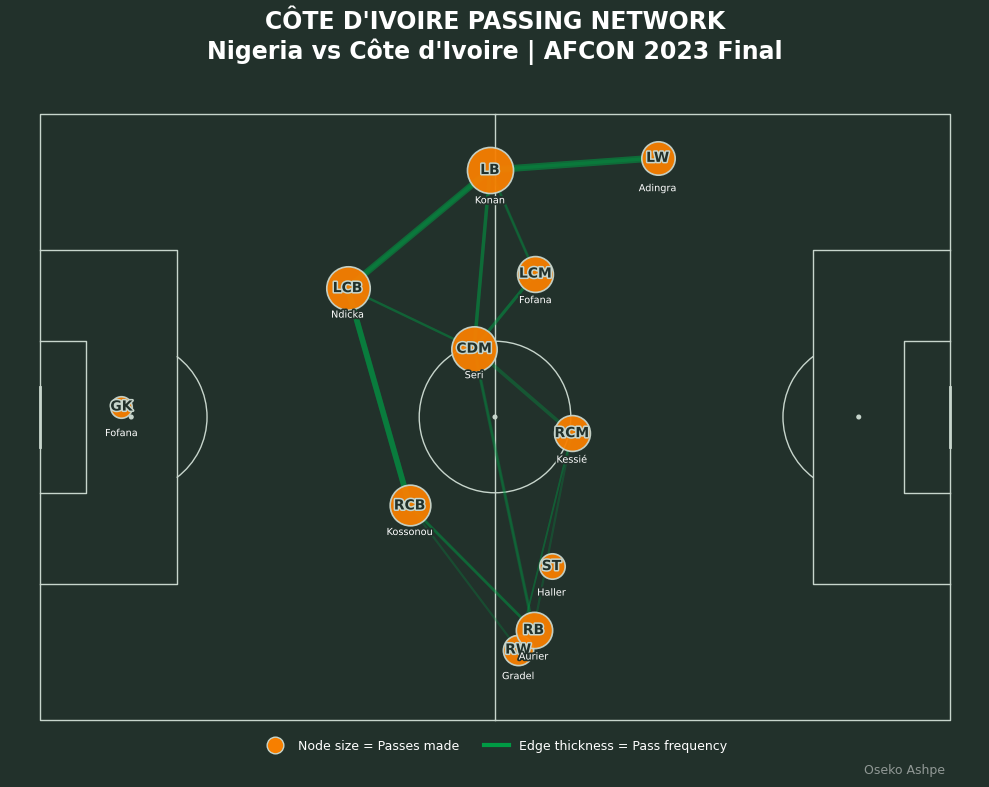

In [25]:
# Colours
bg         = "#22312b"
line       = "#c7d5cc"
node_color = "#F77F00"
edge_color = "#009A44"

# Pitch
pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color=bg,
    line_color=line,
    linewidth=1.0
)

fig, ax = pitch.draw(figsize=(10, 8))
fig.set_facecolor(bg)

# Position lookup dict 
pos = node_data.set_index("player")[["x", "y"]].to_dict("index")

# Edges
links_plot = links.sort_values(
    "pass_count",
    ascending=False
).head(30).copy()

max_passes = (
    links_plot["pass_count"].max()
    if not links_plot.empty else 1
)

w_min, w_max = 0.5, 5.0

for _, row in links_plot.iterrows():

    passer   = row["player"]
    receiver = row["pass_recipient"]

    if passer not in pos or receiver not in pos:
        continue

    start = pos[passer]
    end   = pos[receiver]

    lw = np.interp(
        row["pass_count"],
        [1, max_passes],
        [w_min, w_max]
    )

    alpha = np.interp(
        row["pass_count"],
        [1, max_passes],
        [0.18, 0.55]
    )

    pitch.lines(
        start["x"], start["y"],
        end["x"], end["y"],
        lw=lw,
        alpha=alpha,
        color=edge_color,
        zorder=2,
        ax=ax
    )

# Nodes
max_marker_size = 1100
min_marker_size = 300

max_passes_made = (
    node_data["passes_made"].max()
    if len(node_data) else 1
)

for _, row in node_data.iterrows():

    size = np.interp(
        row["passes_made"],
        [1, max_passes_made],
        [min_marker_size, max_marker_size]
    )

    is_gk = (
        str(row.get("position_abbreviation", "")).upper()
        == "GK"
    )

    if is_gk:
        size *= 0.65

    pitch.scatter(
        row["x"],
        row["y"],
        s=size,
        color=node_color,
        edgecolor=line,
        linewidth=1.2,
        alpha=0.95,
        zorder=3,
        ax=ax
    )

    # Position label
    pos_label = row.get("position_abbreviation")

    if isinstance(pos_label, str) and pos_label.strip():
        center_label = pos_label.strip().upper()
    else:
        parts = row["player"].split()
        center_label = (
            parts[0][0].upper() +
            (parts[-1][0].upper() if len(parts) > 1 else "")
        )

    txt = ax.text(
        row["x"],
        row["y"],
        center_label,
        ha="center",
        va="center",
        color=bg,
        fontsize=10,
        fontweight="bold",
        zorder=4
    )

    txt.set_path_effects([
        pe.withStroke(
            linewidth=2.2,
            foreground=line
        )
    ])

    # Player surname
    surname = row["player"].split()[-1]

    offset = 4 if row["y"] < 15 else 3.5

    name_txt = ax.text(
        row["x"],
        row["y"] + offset,
        surname,
        ha="center",
        va="center",
        color="white",
        fontsize=7,
        zorder=4
    )

    name_txt.set_path_effects([
        pe.withStroke(
            linewidth=2.5,
            foreground=bg
        )
    ])

# Legend
legend_elements = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=node_color,
        markeredgecolor=line,
        markersize=12,
        linestyle='None',
        label='Node size = Passes made'
    ),

    Line2D(
        [0], [0],
        color=edge_color,
        lw=3,
        label='Edge thickness = Pass frequency'
    )
]

legend = ax.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=9,
    frameon=False,
    labelcolor='white'
)

# Match Info 
match_row = df_match[
    df_match["match_id"] == match_id
].iloc[0]

home = match_row["home_team_name"]
away = match_row["away_team_name"]

# Title 
ax.set_title(
    f"{team_name.upper()} PASSING NETWORK\n"
    f"{home} vs {away} | AFCON 2023 Final",
    fontsize=17,
    color="white",
    fontweight="bold",
    pad=18
)

# Watermark 
fig.text(
    0.95,
    0.03,
    "Oseko Ashpe",
    fontsize=9,
    color="white",
    alpha=0.5,
    ha="right",
    va="bottom"
)

# Save & Show 
plt.tight_layout()

plt.savefig(
    "passing_network.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=bg
)

plt.show()

<a id="interpretation"></a>
## 8. Interpretation

### 8.1 What the Network Shows

The passing network above represents **Ivory Coast's starting XI** during the AFCON 2023 Final against Nigeria, using only open-play completed passes made **before the first substitution**.

- **Node position** reflects each player's average on-ball location . This approximates their actual pitch position during the match.
- **Node size** scales with the number of passes the player made. Larger nodes are more involved in build-up.
- **Edge width** reflects the volume of passes between two players. Thicker lines indicate a stronger passing relationship.

## 8.2 Structural shape
The network is heavily skewed toward Ivory Coast's left flank and central spine, with very little presence on the right wing. Ndicka (LCB), Seri (CDM), and Konan (LB) form a tight vertical triangle through the middle-left of the pitch, this was clearly the team's primary build-up channel.

### 8.2.1 Key connectors
- Seri (CDM) sits at the heart of the network with connections in almost every direction (LB, LCM, RCM), the classic pivot role, receiving from the back and distributing forward.

- Konan (LB) has the single heaviest connection on the pitch (thick edge to Ndicka) and also feeds the left winger Adingra directly, suggesting Ivory Coast built attacks down the left side through the fullback.

- Kessié (RCM) is the right-sided counterpart to Seri but with thinner, more varied connections, less of a focal point, more of a relay to Haller and the front players.

### 8.2.2 Weak points
- Aurier (RB) and Gradel (RW) are almost isolated, clustered tightly at the bottom with barely any edges, the right side of the pitch was disconnected from the main passing structure, meaning attacks rarely progressed down that flank.
  
Overall, this shape suggests a left-sided, central-progression approach: Ndicka and Konan building from the back-left, channeling through Seri in midfield, then out wide to Adingra or forward to Haller/Kessié. The right side (Aurier/Gradel) functioned more as an isolated outlet than a structural pillar of possession, worth flagging as a potential imbalance if Nigeria's defense was set up to press that side.

<a id="summary"></a>
## 9. Summary statistics 

In [26]:
# --- Summary statistics ---
print("Passing Network Summary")
print("-" * 40)
print(f"Total completed open-play passes (before 1st sub): {len(completions)}")
print(f"Passing pairs shown in network (min. 4 passes):    {len(links)}")

print("\nTop 5 Passing Combinations")
print("-" * 40)

top_links = (
    links
    .sort_values('pass_count', ascending=False)
    .head(5)
    .rename(columns={
        'player': 'Passer',
        'pass_recipient': 'Recipient',
        'pass_count': 'Passes'
    })
    .reset_index(drop=True)
)
top_links.index = top_links.index + 1
top_links

Passing Network Summary
----------------------------------------
Total completed open-play passes (before 1st sub): 268
Passing pairs shown in network (min. 4 passes):    24

Top 5 Passing Combinations
----------------------------------------


,Passer,Recipient,Passes
1,Ghislain Konan,Simon Adingra,18
2,Obite Evan Ndicka,Ghislain Konan,17
3,Obite Evan Ndicka,Odilon Kossonou,15
4,Odilon Kossonou,Obite Evan Ndicka,14
5,Jean Michaël Seri,Franck Yannick Kessié,9
